# NLP task 1 – Text Classification
## NNLM (TF Hub)

## Imports & Setup


In [1]:
# Install tensorflow_hub if not already installed
import subprocess
import sys

try:
    import tensorflow_hub as hub
except ImportError:
    print("Installing tensorflow_hub...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow_hub"])

import tensorflow_hub as hub
import os, time, warnings, re, platform, sys
import xml.etree.ElementTree as ET
from collections import Counter
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
for _pkg in ['stopwords', 'punkt', 'wordnet', 'punkt_tab', 'omw-1.4']:
    nltk.download(_pkg, quiet=True)
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"Hub        : {hub.__version__}")
print(f"GPU        : {bool(tf.config.list_physical_devices('GPU'))}")

Installing tensorflow_hub...


C:\Users\User\anaconda3\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version



TensorFlow : 2.21.0
Hub        : 0.16.1
GPU        : False


In [2]:
ARXIV_CATEGORIES = {'cs.LG':'Machine Learning', 'astro-ph': 'Astrophysics', 'math.CO': 'Mathematics', 'q-bio':'Biology'}
PAPERS_PER_CLASS = 500
ARXIV_BATCH  = 100
ARXIV_SLEEP  = 3.0
ARXIV_CSV    = 'arxiv_dataset.csv'
MAX_SEQ_LEN  = 200          # used for EDA coverage plot only
BATCH_SIZE   = 64
EPOCHS_NNLM  = 15
TEST_SIZE    = 0.20
RANDOM_SEED  = 42

# Three TF-Hub NNLM models (from week8_text_classification.ipynb)
NNLM_50_URL       = "https://tfhub.dev/google/nnlm-en-dim50/2"
NNLM_50_NORM_URL  = "https://tfhub.dev/google/nnlm-en-dim50-with-normalization/2"
NNLM_128_NORM_URL = "https://tfhub.dev/google/nnlm-en-dim128-with-normalization/2"

NUM_CLASSES  = len(ARXIV_CATEGORIES)
CLASS_NAMES  = list(ARXIV_CATEGORIES.values())
PALETTE      = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']
OUT_EDA          = 'outputs/eda'
OUT_NNLM50       = 'outputs/nnlm50'
OUT_NNLM50_NORM  = 'outputs/nnlm50_norm'
OUT_NNLM128_NORM = 'outputs/nnlm128_norm'
OUT_COMPARISON   = 'outputs/comparison'

for _d in [OUT_EDA, OUT_NNLM50, OUT_NNLM50_NORM, OUT_NNLM128_NORM, OUT_COMPARISON]:
    os.makedirs(_d, exist_ok=True)
print(f"Output directories ready.")

Output directories ready.


## Data Collection

In [3]:
ARXIV_API   = "http://export.arxiv.org/api/query"
ATOM_NS     = {'atom': 'http://www.w3.org/2005/Atom'}

def fetch_arxiv(category: str, max_results: int = 500, batch_size: int = 100, sleep: float = 3.0) -> list:
    """Retrieve paper records from the arXiv API for a given subject category."""
    papers = []

    for start in range(0, max_results, batch_size):
        fetch_n = min(batch_size, max_results - start)
        params  = { 'search_query': f'cat:{category}', 'start': start, 'max_results': fetch_n, 'sortBy': 'submittedDate','sortOrder': 'descending'}
        print(f"[{category}] start={start} | requesting {fetch_n} papers …", end=' ')
        try:
            resp = requests.get(ARXIV_API, params=params, timeout=30)
            resp.raise_for_status()
        except requests.RequestException as e:
            print(f"ERROR – {e}")
            break

        root    = ET.fromstring(resp.content)
        entries = root.findall('atom:entry', ATOM_NS)
        print(f"received {len(entries)}")

        if not entries:
            break
        for entry in entries:
            title    = entry.find('atom:title', ATOM_NS)
            abstract = entry.find('atom:summary', ATOM_NS)
            if title is not None and abstract is not None:
                t = re.sub(r'\s+', ' ', title.text.strip())
                a = re.sub(r'\s+', ' ', abstract.text.strip())
                if len(a) > 80:                  
                    papers.append({'text': t + '. ' + a, 'label': category})

        if start + batch_size < max_results:
            time.sleep(sleep)                        

    print(f"{len(papers)} usable papers collected for '{category}'")
    return papers


def build_arxiv_dataset(categories: dict, papers_per_class: int = 500) -> pd.DataFrame:
    """
    Iterate over ARXIV_CATEGORIES, fetch papers for each, and return a
    combined DataFrame with human-readable 'label' column.
    """
    all_papers = []
    for cat_code, cat_label in categories.items():
        print(f"\nFetching '{cat_label}'  (arXiv: {cat_code})")
        papers = fetch_arxiv(cat_code, papers_per_class)
        for p in papers:
            p['label'] = cat_label          # replace code with readable name
        all_papers.extend(papers)

    df = pd.DataFrame(all_papers)
    print(f"\nTotal collected: {len(df):,} papers")
    print(df['label'].value_counts().to_string())
    return df


In [4]:
if os.path.exists(ARXIV_CSV):
    print(f"Loading cached dataset from '{ARXIV_CSV}' …")
    df = pd.read_csv(ARXIV_CSV)
    print(f"{len(df):,} papers loaded.")
else:
    print("No cache found – fetching from arXiv API …")
    print(f"~{PAPERS_PER_CLASS * len(ARXIV_CATEGORIES)} papers {ARXIV_SLEEP}s sleep {int(PAPERS_PER_CLASS/ARXIV_BATCH * len(ARXIV_CATEGORIES) * ARXIV_SLEEP / 60) + 1} min estimated")
    df = build_arxiv_dataset(ARXIV_CATEGORIES, PAPERS_PER_CLASS)
    df.to_csv(ARXIV_CSV, index=False)
    print(f"Saved to '{ARXIV_CSV}'")

df.head()

Loading cached dataset from 'arxiv_dataset.csv' …
1,999 papers loaded.


,text,label
0,The Latent Color Subspace: Emergent Order in H...,Machine Learning
1,Spatial-TTT: Streaming Visual-based Spatial In...,Machine Learning
2,"Matching Features, Not Tokens: Energy-Based Fi...",Machine Learning
3,Examining Reasoning LLMs-as-Judges in Non-Veri...,Machine Learning
4,Separable neural architectures as a primitive ...,Machine Learning


## Exploratory Data Analysis

In [5]:
def eda_overview(df: pd.DataFrame) -> pd.DataFrame:
    """Print statistical summary; add text_len and word_count columns."""
    df = df.copy()
    df['text_len']   = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len()

    print("=" * 55)
    print("DATASET OVERVIEW")
    print("=" * 55)
    print(f"Total papers :{len(df):,}")
    print(f"Domains : {sorted(df['label'].unique())}")
    print(f"Missing values: {df[['text','label']].isnull().sum().to_dict()}")
    print(f"Duplicates: {df.duplicated(subset='text').sum()}")
    print("Class distribution:")
    print(df['label'].value_counts().to_string())
    print("Word count statistics:")
    print(df['word_count'].describe().round(1).to_string())
    return df

df = eda_overview(df)

DATASET OVERVIEW
Total papers :1,999
Domains : ['Astrophysics', 'Biology', 'Machine Learning', 'Mathematics']
Missing values: {'text': 0, 'label': 0}
Duplicates: 0
Class distribution:
label
Machine Learning    500
Mathematics         500
Biology             500
Astrophysics        499
Word count statistics:
count    1999.0
mean      158.2
std        62.2
min        20.0
25%       110.0
50%       153.0
75%       203.5
max       330.0


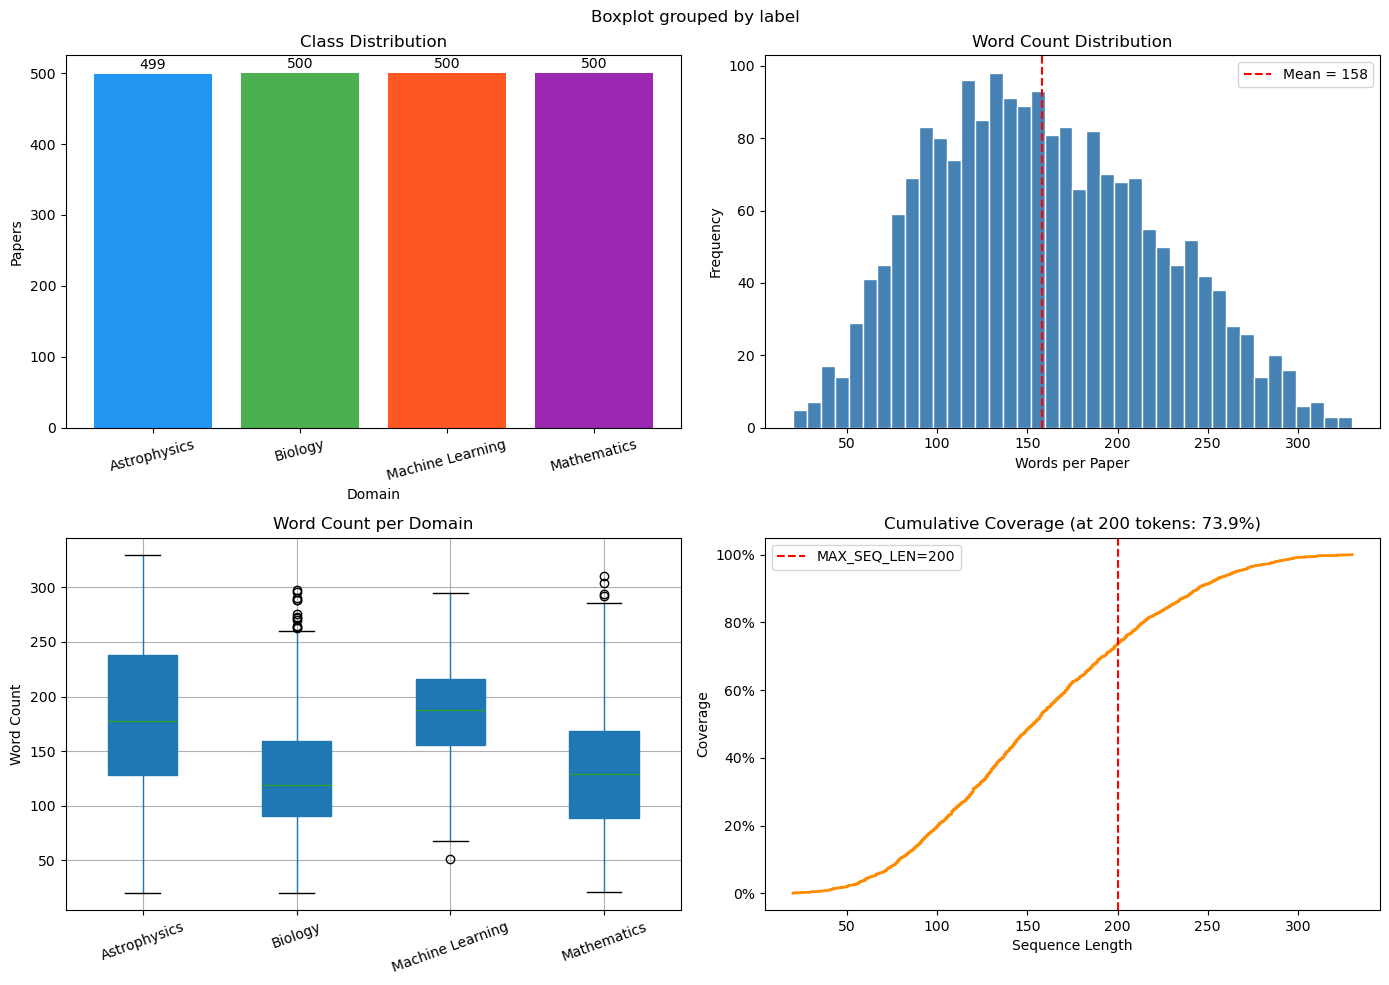

Saved 'outputs/eda\eda_overview.png'


In [6]:
def plot_eda(df: pd.DataFrame, palette=PALETTE, save_dir: str = OUT_EDA) -> None:
    """Four-panel EDA figure: class counts, word-count distribution,
    per-class box-plot, and cumulative sequence-length coverage."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Exploratory Data Analysis – arXiv Dataset", fontsize=15, fontweight='bold')

    # Class distribution
    counts = df['label'].value_counts().sort_index()
    axes[0,0].bar(counts.index, counts.values, color=palette)
    axes[0,0].set_title("Class Distribution")
    axes[0,0].set_xlabel("Domain"); axes[0,0].set_ylabel("Papers")
    axes[0,0].tick_params(axis='x', rotation=15)
    for bar, v in zip(axes[0,0].patches, counts.values):
        axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(v), ha='center', va='bottom')

    # Word count histogram
    axes[0,1].hist(df['word_count'], bins=40, color='steelblue', edgecolor='white')
    axes[0,1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f"Mean = {df['word_count'].mean():.0f}")
    axes[0,1].set_title("Word Count Distribution")
    axes[0,1].set_xlabel("Words per Paper"); axes[0,1].set_ylabel("Frequency")
    axes[0,1].legend()

    # Per-domain word count box-plot
    df.boxplot(column='word_count', by='label', ax=axes[1,0], patch_artist=True)
    axes[1,0].set_title("Word Count per Domain")
    plt.sca(axes[1,0]); plt.xticks(rotation=20)
    axes[1,0].set_xlabel(""); axes[1,0].set_ylabel("Word Count")

    # Cumulative coverage curve
    sorted_wc  = np.sort(df['word_count'].values)
    cumulative = np.arange(1, len(sorted_wc)+1) / len(sorted_wc)
    axes[1,1].plot(sorted_wc, cumulative, color='darkorange', lw=2)
    axes[1,1].axvline(MAX_SEQ_LEN, color='red', linestyle='--', label=f"MAX_SEQ_LEN={MAX_SEQ_LEN}")
    cov = (df['word_count'] <= MAX_SEQ_LEN).mean()
    axes[1,1].set_title(f"Cumulative Coverage (at {MAX_SEQ_LEN} tokens: {cov:.1%})")
    axes[1,1].set_xlabel("Sequence Length"); axes[1,1].set_ylabel("Coverage")
    axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    axes[1,1].legend()

    plt.tight_layout()
    fname = os.path.join(save_dir, "eda_overview.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved '{fname}'")

plot_eda(df)

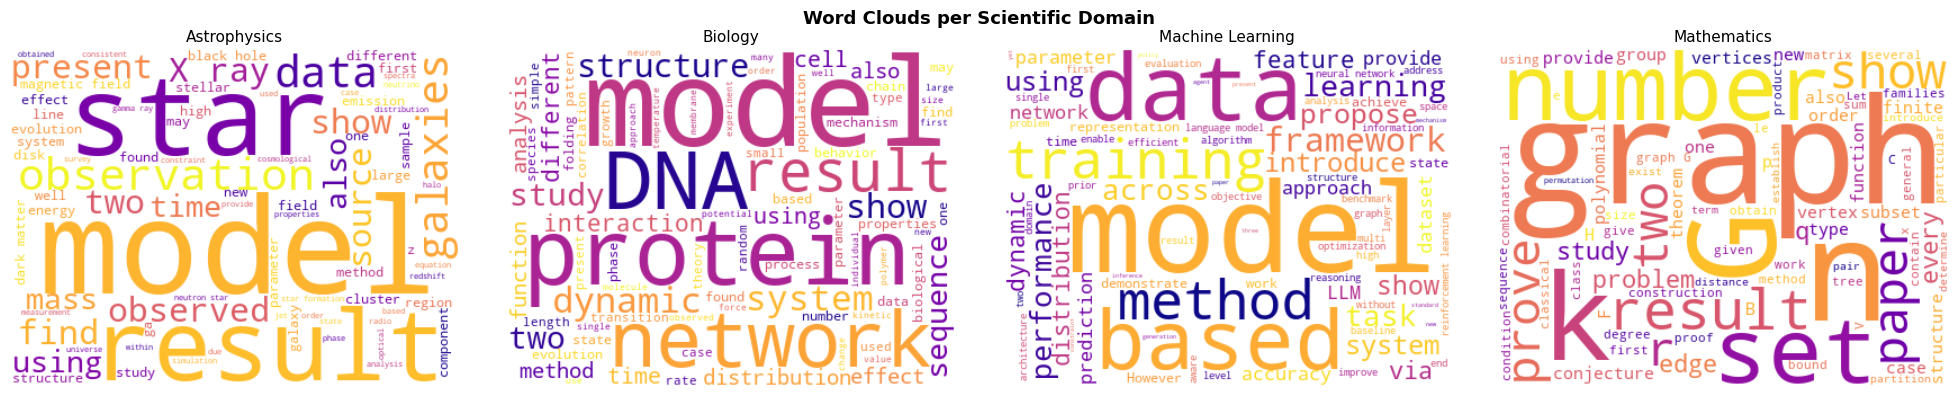

Saved 'outputs/eda\wordclouds.png'


In [7]:
def plot_wordclouds(df: pd.DataFrame, save_dir: str = OUT_EDA) -> None:
    """One word cloud per scientific domain (stopwords removed)."""
    domains     = sorted(df['label'].unique())
    stop_words  = set(stopwords.words('english'))
    fig, axes   = plt.subplots(1, len(domains), figsize=(20, 4))
    fig.suptitle("Word Clouds per Scientific Domain", fontsize=13, fontweight='bold')

    for ax, domain in zip(axes, domains):
        text = " ".join(df.loc[df['label'] == domain, 'text'])
        wc = WordCloud(width=400, height=300, background_color='white', stopwords=stop_words, max_words=80, colormap='plasma').generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(domain, fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    fname = os.path.join(save_dir, "wordclouds.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved '{fname}'")

plot_wordclouds(df)

## Text Preprocessing

In [8]:
_lemmatizer = WordNetLemmatizer()
_stopwords  = set(stopwords.words('english'))

def preprocess_text(text: str) -> str:
    """
    Clean a single document:
    """
    text = text.lower()
    text = re.sub(r'\$[^$]*\$', '', text)
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)         
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [_lemmatizer.lemmatize(t) for t in text.split() if t not in _stopwords and len(t) > 2]
    return " ".join(tokens)

def preprocess_corpus(texts) -> list:
    """Apply preprocess_text to every document; return cleaned list."""
    return [preprocess_text(t) for t in texts]

print("Preprocessing corpus …")
df['clean_text'] = preprocess_corpus(df['text'])
df['clean_wc']   = df['clean_text'].str.split().str.len()

print(f"Avg word count before : {df['word_count'].mean():.0f}")
print(f"Avg word count after: {df['clean_wc'].mean():.0f}")
print("\nSample before:", df['text'].iloc[0][:150])
print("Sample after :", df['clean_text'].iloc[0][:150])


Preprocessing corpus …
Avg word count before : 158
Avg word count after: 94

Sample before: The Latent Color Subspace: Emergent Order in High-Dimensional Chaos. Text-to-image generation models have advanced rapidly, yet achieving fine-grained
Sample after : latent color subspace emergent order highdimensional chaos texttoimage generation model advanced rapidly yet achieving finegrained control generated i


## Label Encoding & Train/Test Split

In [9]:
le= LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
NUM_CLASSES= len(le.classes_)
CLASS_NAMES= list(le.classes_)
print(f"Encoded classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")
_idx = np.arange(len(df))
train_idx, test_idx = train_test_split(_idx, test_size=TEST_SIZE,
                                       stratify=df['label_enc'].values,
                                       random_state=RANDOM_SEED)
X_train_raw  = df['clean_text'].values[train_idx]   # cleaned — for reference
X_test_raw   = df['clean_text'].values[test_idx]
X_train_orig = df['text'].values[train_idx]          # raw text — fed to hub models
X_test_orig  = df['text'].values[test_idx]
y_train     = df['label_enc'].values[train_idx]
y_test      = df['label_enc'].values[test_idx]
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f"Train : {len(X_train_raw):,}  |  Test : {len(X_test_raw):,}")

Encoded classes: {'Astrophysics': np.int64(0), 'Biology': np.int64(1), 'Machine Learning': np.int64(2), 'Mathematics': np.int64(3)}
Train : 1,599  |  Test : 400


In [10]:
def build_nnlm_classifier(num_classes: int, nnlm_url: str, trainable: bool = True) -> tf.keras.Model:
    class _NNLMClassifier(tf.keras.Model):
        def __init__(self):
            super().__init__(name="NNLM_Classifier")
            self.nnlm   = hub.KerasLayer(nnlm_url, trainable=trainable,
                                         name="nnlm_embedding")
            self.dense1 = tf.keras.layers.Dense(16, activation="relu",  name="dense1")
            self.out    = tf.keras.layers.Dense(num_classes, activation="softmax",
                                                name="output")

        def call(self, inputs, training=None):
            x = self.nnlm(inputs, training=training)
            x = self.dense1(x,    training=training)
            return self.out(x,    training=training)

    model = _NNLMClassifier()
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

def evaluate_model(model, X_test, y_test_cat, y_test_int, class_names: list,
                   model_name: str, save_dir: str = '.') -> dict:
    """Generate predictions, print classification report, plot confusion matrix."""
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc  = accuracy_score(y_test_int, y_pred)
    prec = precision_score(y_test_int, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test_int, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test_int, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} – Classification Report")
    print(f"{'='*55}")
    print(classification_report(y_test_int, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_test_int, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    fname = os.path.join(save_dir, f"cm_{model_name.replace(' ','_').lower()}.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved '{fname}'")
    return {"model": model_name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

def plot_history(history, model_name: str, save_dir: str = '.') -> None:
    """Side-by-side accuracy and loss curves for a trained Keras model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Training History – {model_name}", fontsize=13, fontweight='bold')

    ax1.plot(history.history['accuracy'],     label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    fname = os.path.join(save_dir, f"history_{model_name.replace(' ','_').lower()}.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved '{fname}'")

CALLBACKS = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1)
]

## NNLM Embeddings (TF Hub)

Three pre-trained models from [TensorFlow Hub](https://tfhub.dev/s?module-type=text-embedding) are compared:

| # | Model | Dim | Notes |
|---|-------|-----|-------|
| 1 | `nnlm-en-dim50/2` | 50 | base model |
| 2 | `nnlm-en-dim50-with-normalization/2` | 50 | punctuation removed |
| 3 | `nnlm-en-dim128-with-normalization/2` | 128 | larger embedding |

### Model 1 – NNLM-50 (`nnlm-en-dim50/2`)

In [11]:
print(f"Building NNLM-50 classifier …  URL: {NNLM_50_URL}")
nnlm50_clf = build_nnlm_classifier(NUM_CLASSES, NNLM_50_URL, trainable=True)
nnlm50_clf.summary()

Building NNLM-50 classifier …  URL: https://tfhub.dev/google/nnlm-en-dim50/2


Model: "NNLM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training NNLM-50 classifier …
Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.2530 - loss: 1.4065 - val_accuracy: 0.2937 - val_loss: 1.3629
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4260 - loss: 1.2791 - val_accuracy: 0.4875 - val_loss: 1.2479
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5810 - loss: 1.1632 - val_accuracy: 0.6000 - val_loss: 1.1370
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6560 - loss: 1.0577 - val_accuracy: 0.6625 - val_loss: 1.0342
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7199 - loss: 0.9593 - val_accuracy: 0.7000 - val_loss: 0.9353
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7477 - loss: 0.8700 - val_accuracy: 0.7000 - val_loss: 0.8558
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7665 - loss: 0.7942 - val_accuracy: 0.7375 - val_loss: 0.7890
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7853 - loss: 0.

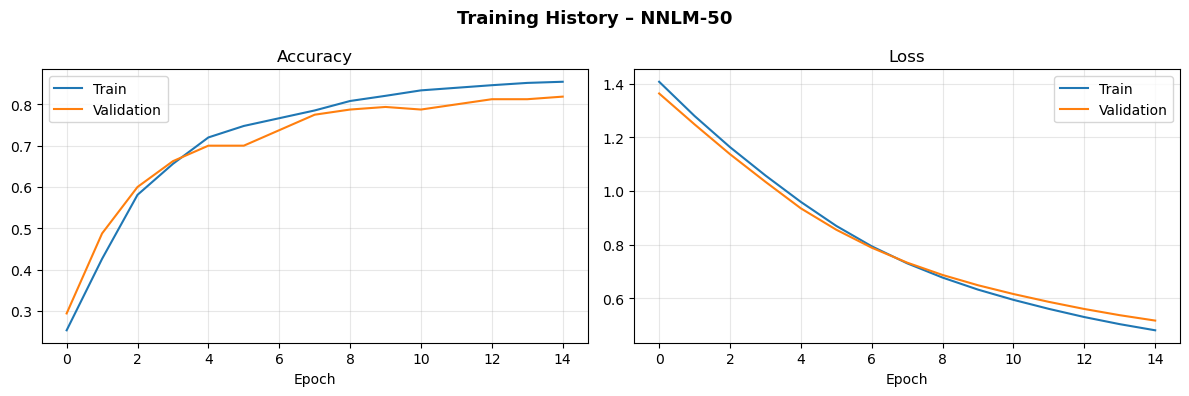

Saved 'outputs/nnlm50\history_nnlm-50.png'


In [12]:
print("\nTraining NNLM-50 classifier …")
t0 = time.time()
nnlm50_history = nnlm50_clf.fit(
    tf.constant(X_train_orig), y_train_cat,
    validation_split=0.10,
    epochs=EPOCHS_NNLM,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7,
                       restore_best_weights=True, verbose=1)],
    verbose=1
)
nnlm50_clf_time = time.time() - t0
print(f"Training time: {nnlm50_clf_time:.1f}s")
plot_history(nnlm50_history, "NNLM-50", save_dir=OUT_NNLM50)


  NNLM-50 – Classification Report
                  precision    recall  f1-score   support

    Astrophysics       0.86      0.91      0.88       100
         Biology       0.82      0.78      0.80       100
Machine Learning       0.92      0.85      0.89       100
     Mathematics       0.86      0.92      0.89       100

        accuracy                           0.86       400
       macro avg       0.87      0.86      0.86       400
    weighted avg       0.87      0.86      0.86       400



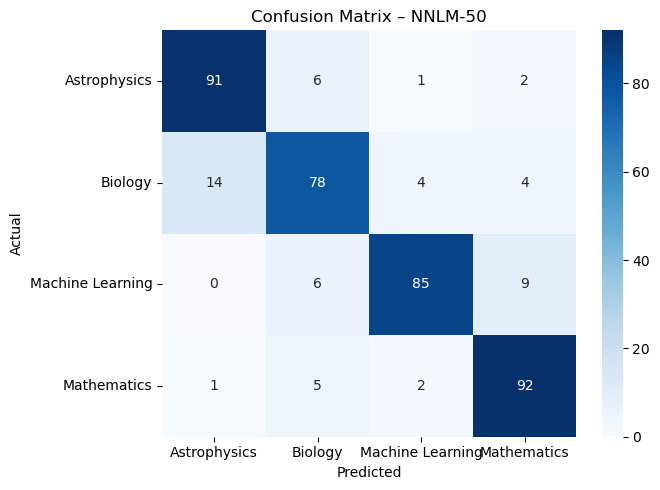

Saved 'outputs/nnlm50\cm_nnlm-50.png'

NNLM-50 >> Accuracy: 0.8650  F1: 0.8645


In [13]:
nnlm50_results = evaluate_model(nnlm50_clf, tf.constant(X_test_orig), y_test_cat,
                                y_test, CLASS_NAMES, "NNLM-50", save_dir=OUT_NNLM50)
nnlm50_results['train_time_sec'] = round(nnlm50_clf_time, 2)
print(f"\nNNLM-50 >> Accuracy: {nnlm50_results['accuracy']:.4f}  F1: {nnlm50_results['f1']:.4f}")

### Model 2 – NNLM-50 with Normalization (`nnlm-en-dim50-with-normalization/2`)

In [14]:
print(f"Building NNLM-50-Norm classifier …  URL: {NNLM_50_NORM_URL}")
nnlm50n_clf = build_nnlm_classifier(NUM_CLASSES, NNLM_50_NORM_URL, trainable=True)
nnlm50n_clf.summary()

Building NNLM-50-Norm classifier …  URL: https://tfhub.dev/google/nnlm-en-dim50-with-normalization/2


Model: "NNLM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training NNLM-50-Norm classifier …
Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.2787 - loss: 1.3687 - val_accuracy: 0.4375 - val_loss: 1.3320
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4566 - loss: 1.2613 - val_accuracy: 0.5000 - val_loss: 1.2455
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5268 - loss: 1.1676 - val_accuracy: 0.5688 - val_loss: 1.1549
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6171 - loss: 1.0671 - val_accuracy: 0.6187 - val_loss: 1.0550
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6942 - loss: 0.9649 - val_accuracy: 0.6812 - val_loss: 0.9519
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7512 - loss: 0.8674 - val_accuracy: 0.7125 - val_loss: 0.8619
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7943 - loss: 0.7817 - val_accuracy: 0.7312 - val_loss: 0.7843
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8214 - los

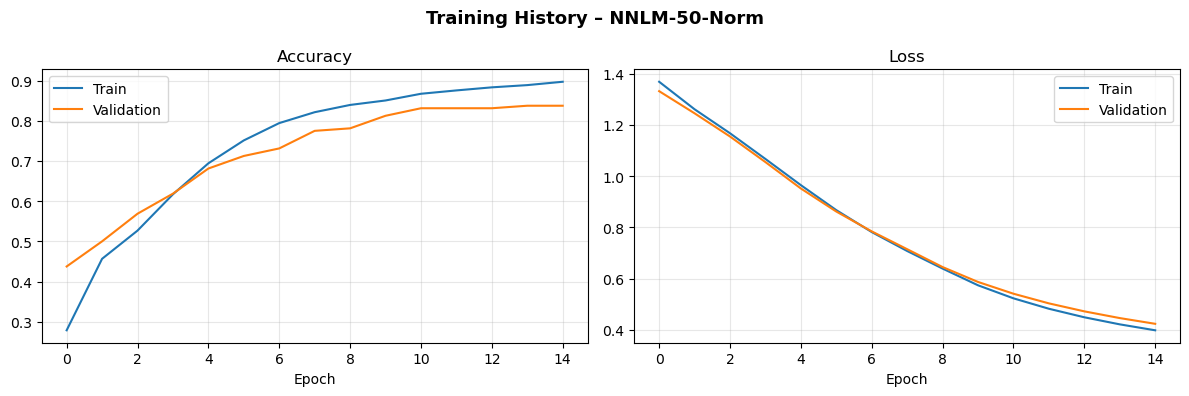

Saved 'outputs/nnlm50_norm\history_nnlm-50-norm.png'


In [15]:
print("\nTraining NNLM-50-Norm classifier …")
t0 = time.time()
nnlm50n_history = nnlm50n_clf.fit(
    tf.constant(X_train_orig), y_train_cat,
    validation_split=0.10,
    epochs=EPOCHS_NNLM,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7,
                       restore_best_weights=True, verbose=1)],
    verbose=1
)
nnlm50n_clf_time = time.time() - t0
print(f"Training time: {nnlm50n_clf_time:.1f}s")
plot_history(nnlm50n_history, "NNLM-50-Norm", save_dir=OUT_NNLM50_NORM)


  NNLM-50-Norm – Classification Report
                  precision    recall  f1-score   support

    Astrophysics       0.94      0.89      0.91       100
         Biology       0.84      0.88      0.86       100
Machine Learning       0.89      0.90      0.90       100
     Mathematics       0.88      0.87      0.87       100

        accuracy                           0.89       400
       macro avg       0.89      0.89      0.89       400
    weighted avg       0.89      0.89      0.89       400



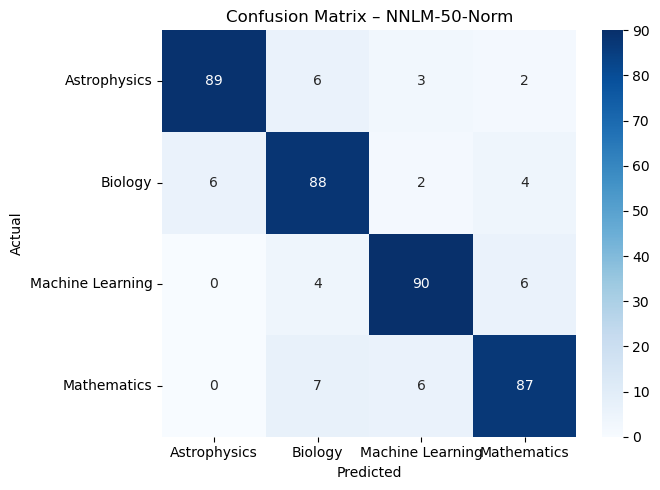

Saved 'outputs/nnlm50_norm\cm_nnlm-50-norm.png'

NNLM-50-Norm >> Accuracy: 0.8850  F1: 0.8853


In [16]:
nnlm50n_results = evaluate_model(nnlm50n_clf, tf.constant(X_test_orig), y_test_cat,
                                 y_test, CLASS_NAMES, "NNLM-50-Norm", save_dir=OUT_NNLM50_NORM)
nnlm50n_results['train_time_sec'] = round(nnlm50n_clf_time, 2)
print(f"\nNNLM-50-Norm >> Accuracy: {nnlm50n_results['accuracy']:.4f}  F1: {nnlm50n_results['f1']:.4f}")

### Model 3 – NNLM-128 with Normalization (`nnlm-en-dim128-with-normalization/2`)

In [17]:
print(f"Building NNLM-128-Norm classifier …  URL: {NNLM_128_NORM_URL}")
nnlm128n_clf = build_nnlm_classifier(NUM_CLASSES, NNLM_128_NORM_URL, trainable=True)
nnlm128n_clf.summary()

Building NNLM-128-Norm classifier …  URL: https://tfhub.dev/google/nnlm-en-dim128-with-normalization/2


Model: "NNLM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training NNLM-128-Norm classifier …
Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3593 - loss: 1.3445 - val_accuracy: 0.5000 - val_loss: 1.2480
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5129 - loss: 1.1865 - val_accuracy: 0.5125 - val_loss: 1.0869
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6171 - loss: 1.0248 - val_accuracy: 0.6750 - val_loss: 0.9387
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7609 - loss: 0.8816 - val_accuracy: 0.7937 - val_loss: 0.8129
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8464 - loss: 0.7599 - val_accuracy: 0.8500 - val_loss: 0.7089
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8867 - loss: 0.6477 - val_accuracy: 0.8687 - val_loss: 0.6099
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9194 - loss: 0.5488 - val_accuracy: 0.8813 - val_loss: 0.5276
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9270 - lo

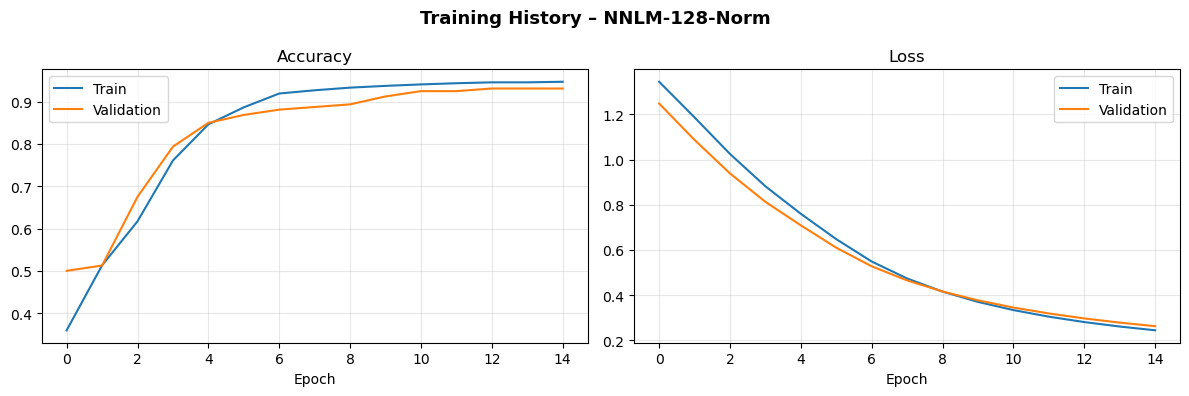

Saved 'outputs/nnlm128_norm\history_nnlm-128-norm.png'


In [18]:
print("\nTraining NNLM-128-Norm classifier …")
t0 = time.time()
nnlm128n_history = nnlm128n_clf.fit(
    tf.constant(X_train_orig), y_train_cat,
    validation_split=0.10,
    epochs=EPOCHS_NNLM,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7,
                       restore_best_weights=True, verbose=1)],
    verbose=1
)
nnlm128n_clf_time = time.time() - t0
print(f"Training time: {nnlm128n_clf_time:.1f}s")
plot_history(nnlm128n_history, "NNLM-128-Norm", save_dir=OUT_NNLM128_NORM)


  NNLM-128-Norm – Classification Report
                  precision    recall  f1-score   support

    Astrophysics       0.97      0.93      0.95       100
         Biology       0.96      0.96      0.96       100
Machine Learning       0.92      0.91      0.91       100
     Mathematics       0.90      0.94      0.92       100

        accuracy                           0.94       400
       macro avg       0.94      0.94      0.94       400
    weighted avg       0.94      0.94      0.94       400



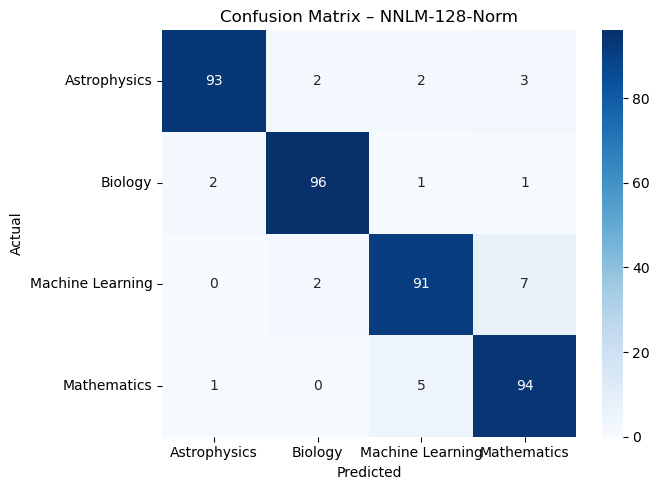

Saved 'outputs/nnlm128_norm\cm_nnlm-128-norm.png'

NNLM-128-Norm >> Accuracy: 0.9350  F1: 0.9352


In [19]:
nnlm128n_results = evaluate_model(nnlm128n_clf, tf.constant(X_test_orig), y_test_cat,
                                  y_test, CLASS_NAMES, "NNLM-128-Norm", save_dir=OUT_NNLM128_NORM)
nnlm128n_results['train_time_sec'] = round(nnlm128n_clf_time, 2)
print(f"\nNNLM-128-Norm >> Accuracy: {nnlm128n_results['accuracy']:.4f}  F1: {nnlm128n_results['f1']:.4f}")

## Performance Comparison


  MODEL COMPARISON SUMMARY
               accuracy  precision  recall      f1  train_time_sec
model                                                             
NNLM-50           0.865     0.8658   0.865  0.8645            7.76
NNLM-50-Norm      0.885     0.8862   0.885  0.8853            6.96
NNLM-128-Norm     0.935     0.9358   0.935  0.9352            7.26


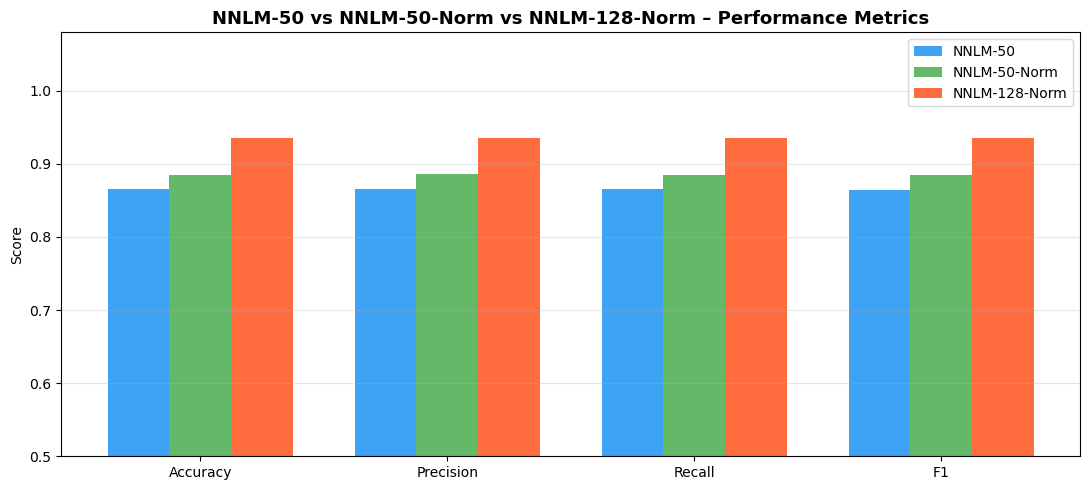

Saved 'outputs/comparison\model_comparison.png'


In [20]:
def compare_models(results_list: list, save_dir: str = OUT_COMPARISON) -> pd.DataFrame:
    """Print summary table and plot grouped bar chart for all three metrics."""
    df_res  = pd.DataFrame(results_list).set_index('model')
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    df_res[metrics] = df_res[metrics].round(4)

    print("\n" + "="*65)
    print("  MODEL COMPARISON SUMMARY")
    print("="*65)
    print(df_res[metrics + ['train_time_sec']].to_string())
    print("="*65)

    x = np.arange(len(metrics))
    width = 0.25
    colors = ['#2196F3', '#4CAF50', '#FF5722']
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (name, row) in enumerate(df_res.iterrows()):
        ax.bar(x + i*width, [row[m] for m in metrics],
               width, label=name, color=colors[i], alpha=0.87)

    ax.set_title("NNLM-50 vs NNLM-50-Norm vs NNLM-128-Norm – Performance Metrics",
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels([m.capitalize() for m in metrics])
    ax.set_ylabel("Score"); ax.set_ylim(0.5, 1.08)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(save_dir, "model_comparison.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved '{fname}'")
    return df_res

results_df = compare_models([nnlm50_results, nnlm50n_results, nnlm128n_results])

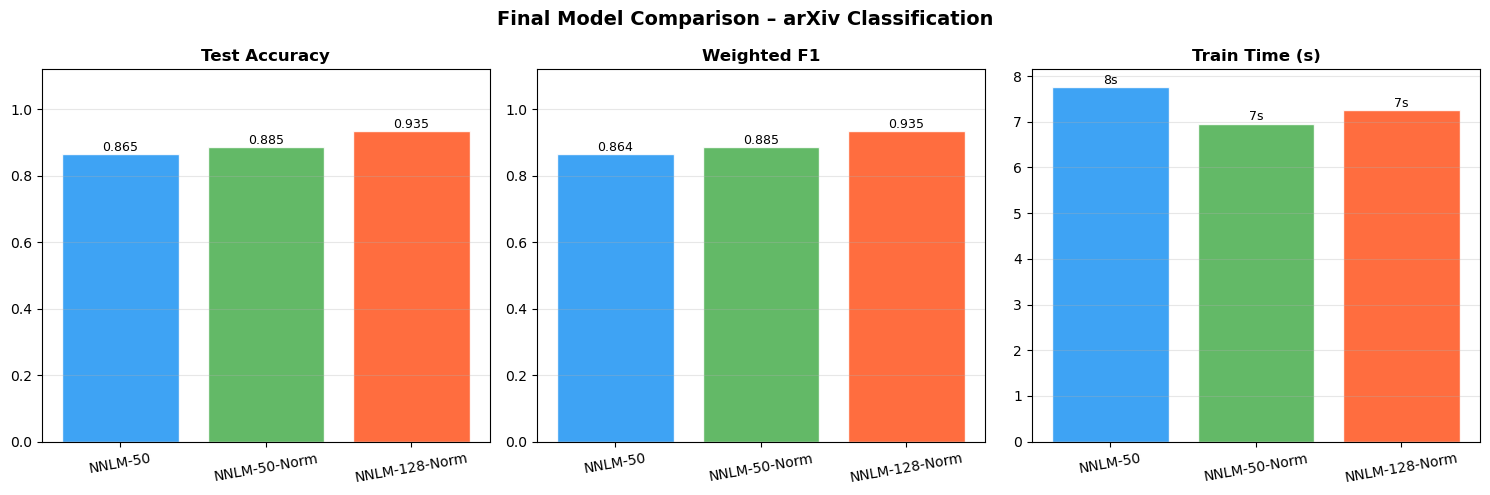

Saved 'outputs/comparison\final_comparison.png'


In [21]:
def plot_final_comparison(results_list: list, save_dir: str = OUT_COMPARISON) -> None:
    """Three-panel figure: accuracy, weighted F1, training time."""
    colors = ['#2196F3', '#4CAF50', '#FF5722']
    models = [r['model'] for r in results_list]
    acc    = [r['accuracy'] for r in results_list]
    f1     = [r['f1'] for r in results_list]
    times  = [r['train_time_sec'] for r in results_list]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Final Model Comparison – arXiv Classification", fontsize=14, fontweight='bold')
    for ax, vals, title in [(axes[0], acc, "Test Accuracy"),
                            (axes[1], f1,  "Weighted F1"),
                            (axes[2], times, "Train Time (s)")]:
        bars = ax.bar(models, vals, color=colors, alpha=0.87, edgecolor='white')
        ax.set_title(title, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=10)
        for b, v in zip(bars, vals):
            lbl = f"{v:.3f}" if title != "Train Time (s)" else f"{v:.0f}s"
            ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01, lbl,
                    ha='center', fontsize=9)
        if title != "Train Time (s)":
            ax.set_ylim(0, 1.12)
    plt.tight_layout()
    fname = os.path.join(save_dir, "final_comparison.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved '{fname}'")

plot_final_comparison([nnlm50_results, nnlm50n_results, nnlm128n_results])

## Environment & Timing Summary

  RUNTIME ENVIRONMENT
OS     : Windows 11
Python : 3.13.5
GPU    : False

  Key packages:
  tensorflow            : 2.21.0
  tensorflow-hub        : 0.16.1
  numpy                 : 2.2.6
  pandas                : 2.2.3
  scikit-learn          : 1.6.1
  matplotlib            : 3.10.0
  wordcloud             : 1.9.6
  nltk                  : 3.9.1

TIMING AND PERFORMANCE SUMMARY
        Model  Train Time (s)  Epochs  Accuracy  F1 Score
      NNLM-50            7.76      15     0.865    0.8645
 NNLM-50-Norm            6.96      15     0.885    0.8853
NNLM-128-Norm            7.26      15     0.935    0.9352


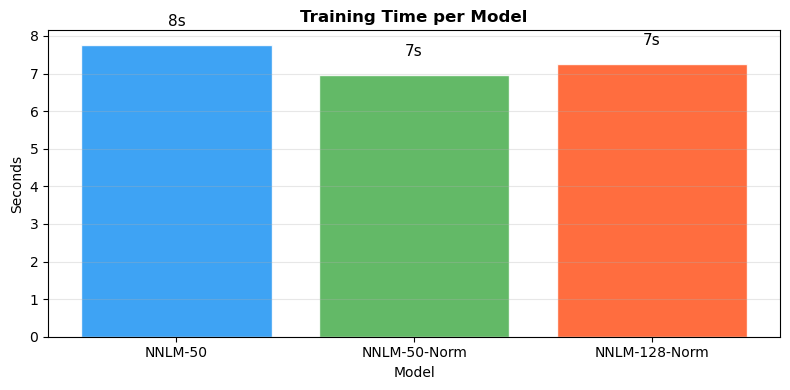

Saved 'outputs/comparison\training_time.png'


In [22]:
import importlib.metadata
def print_environment() -> None:
    print("=" * 60)
    print("  RUNTIME ENVIRONMENT")
    print("=" * 60)
    print(f"OS     : {platform.system()} {platform.release()}")
    print(f"Python : {sys.version.split()[0]}")
    gpus = tf.config.list_physical_devices('GPU')
    print(f"GPU    : {bool(gpus)}")
    for g in gpus:
        print(f"  {g.name}")
    pkgs = ['tensorflow', 'tensorflow-hub', 'numpy', 'pandas',
            'scikit-learn', 'matplotlib', 'wordcloud', 'nltk']
    print("\n  Key packages:")
    for p in pkgs:
        try:
            v = importlib.metadata.version(p)
        except Exception:
            v = "not found"
        print(f"  {p:<22}: {v}")
    print("=" * 60)

print_environment()

timing = pd.DataFrame({
    'Model'         : ['NNLM-50', 'NNLM-50-Norm', 'NNLM-128-Norm'],
    'Train Time (s)': [nnlm50_results['train_time_sec'],
                       nnlm50n_results['train_time_sec'],
                       nnlm128n_results['train_time_sec']],
    'Epochs'        : [len(nnlm50_history.history['loss']),
                       len(nnlm50n_history.history['loss']),
                       len(nnlm128n_history.history['loss'])],
    'Accuracy'      : [round(nnlm50_results['accuracy'], 4),
                       round(nnlm50n_results['accuracy'], 4),
                       round(nnlm128n_results['accuracy'], 4)],
    'F1 Score'      : [round(nnlm50_results['f1'], 4),
                       round(nnlm50n_results['f1'], 4),
                       round(nnlm128n_results['f1'], 4)]
})
print("\nTIMING AND PERFORMANCE SUMMARY")
print(timing.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(timing['Model'], timing['Train Time (s)'],
              color=['#2196F3', '#4CAF50', '#FF5722'], alpha=0.87, edgecolor='white')
ax.set_title("Training Time per Model", fontsize=12, fontweight='bold')
ax.set_xlabel("Model"); ax.set_ylabel("Seconds")
for b, v in zip(bars, timing['Train Time (s)']):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{v:.0f}s",
            ha='center', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fname = os.path.join(OUT_COMPARISON, "training_time.png")
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved '{fname}'"  )